# Projeto 1: gastos com o cartão de pagamento do governo federal

## Dados
- Fonte: Portal da Transparência, Cartão de Pagamento do Governo Federal (CPGF).
- Arquivo: extrato de agosto de 2026 (`202608_CPGF.csv`), com 15.237 transações e 15 colunas.
- O "mês do extrato" é agosto, mas as transações que vi até agora são de julho. Falta conferir o período exato.
- Para abrir o arquivo foi preciso usar o padrão brasileiro: colunas separadas por `;`, acentos em `latin1` e decimais com vírgula.

## Passo a passo do raciocínio
1. **Total gasto:** R/$ 11,72 milhões no extrato.
2. **Valores faltando:** `df.info()` mostrou que 3.926 linhas não têm data nem CPF do portador.
3. **Investigação:** filtrei essas linhas e todas eram transações sigilosas ("Informações protegidas por sigilo").
4. **Validação:** a contagem de transações sigilosas (3.926) é igual à de linhas sem data. Então os dados faltando não são erro, são o sigilo.
5. **Tipos de transação:** agrupei por tipo com `groupby`.
6. **Órgãos:** agrupei por órgão superior, primeiro com tudo junto e depois só com o gasto sigiloso.

## Resultados até agora
**Para onde vai o dinheiro (por tipo)**
- Compras: R\$ 6,20 milhões (53%)
- Sigiloso: R\$ 4,53 milhões (39%)
- Saques em dinheiro: R\$ 0,99 milhão (8%)

**Quem gasta (por órgão)**
- São 29 órgãos superiores, mas 3 concentram 62% do total: Justiça e Segurança Pública (R\$ 3,81 mi), Defesa (R\$ 1,83 mi) e Presidência da República (R\$ 1,66 mi).

**Onde está o sigilo**
- Todo o gasto sigiloso está em só 3 órgãos: Justiça e Segurança Pública (R\$ 2,85 mi, 75% do gasto do órgão), Presidência da República (R\$ 1,65 mi, 99%) e Fazenda (R\$ 0,03 mi, 18%).
- Validação: a soma dos três dá exatamente os R\$ 4,53 milhões sigilosos.
- Isso muda o ranking: olhando só o gasto aberto, a Defesa fica em 1º lugar, a Justiça cai para R\$ 0,97 mi e a Presidência fica com cerca de R\$ 11 mil. Um ranking que mistura gasto aberto e sigiloso engana.

## Cuidados e limitações
- O sigilo é permitido por lei. Os dados mostram onde ele está e quanto é, não o motivo.
- Órgãos com muitas operações de campo, como polícia e forças armadas, tendem a usar mais o cartão. Gastar mais não quer dizer gastar errado.
- Os dados trazem nomes de servidores, mas a análise é por órgão, não por pessoa.
- Até aqui é só 1 extrato mensal.

## Próximos passos
- Valor típico de uma compra e valores fora do padrão.
- Analisar as datas das transações.

In [2]:
import pandas as pd

df = pd.read_csv("202608_CPGF.csv", sep=";", encoding="latin1", decimal=",")

print(df.shape)
df.head()

(15237, 15)


,CÓDIGO ÓRGÃO SUPERIOR,NOME ÓRGÃO SUPERIOR,CÓDIGO ÓRGÃO,NOME ÓRGÃO,CÓDIGO UNIDADE GESTORA,NOME UNIDADE GESTORA,ANO EXTRATO,MÊS EXTRATO,CPF PORTADOR,NOME PORTADOR,CNPJ OU CPF FAVORECIDO,NOME FAVORECIDO,TRANSAÇÃO,DATA TRANSAÇÃO,VALOR TRANSAÇÃO
0,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,8,***.609.911-**,ISABELA RODRIGUES TEIXEIRA,56953324000107,VLB COMERCIO VAREJISTA DE FERRAGENS LTDA,COMPRA A/V - R$ - APRES,13/07/2026,97.49
1,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,8,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,36949823000105,POLAR TINTAS BRASILIA COMERCIO DE TINTAS LTDA,COMPRA A/V - R$ - APRES,16/07/2026,114.50
2,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,8,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,-2,NAO SE APLICA,SAQUE CASH/ATM BB,13/07/2026,255.00
3,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,8,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,-2,NAO SE APLICA,SAQUE CASH/ATM BB,13/07/2026,30.00
4,63000,Advocacia-Geral da União,63000,Advocacia-Geral da União - Unidades com víncul...,110161,SUPERINTENDENCIA REG. DE ADMIN. DA 1ª REGIAO,2026,8,***.562.861-**,ANTONIO CARLOS MELO DOS SANTOS,-2,NAO SE APLICA,SAQUE CASH/ATM BB,08/07/2026,50.00


In [3]:
df.info()

total = df["VALOR TRANSAÇÃO"].sum()
print("Total gasto no extrato:", total)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15237 entries, 0 to 15236
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CÓDIGO ÓRGÃO SUPERIOR   15237 non-null  int64  
 1   NOME ÓRGÃO SUPERIOR     15237 non-null  object 
 2   CÓDIGO ÓRGÃO            15237 non-null  int64  
 3   NOME ÓRGÃO              15237 non-null  object 
 4   CÓDIGO UNIDADE GESTORA  15237 non-null  int64  
 5   NOME UNIDADE GESTORA    15237 non-null  object 
 6   ANO EXTRATO             15237 non-null  int64  
 7   MÊS EXTRATO             15237 non-null  int64  
 8   CPF PORTADOR            11311 non-null  object 
 9   NOME PORTADOR           15237 non-null  object 
 10  CNPJ OU CPF FAVORECIDO  15237 non-null  int64  
 11  NOME FAVORECIDO         15237 non-null  object 
 12  TRANSAÇÃO               15237 non-null  object 
 13  DATA TRANSAÇÃO          11311 non-null  object 
 14  VALOR TRANSAÇÃO         15237 non-null

In [4]:
sem_data = df[df["DATA TRANSAÇÃO"].isna()]

print("Linhas sem data:", len(sem_data))
print("Valor dessas linhas:", round(sem_data["VALOR TRANSAÇÃO"].sum(), 2))
sem_data[["NOME ÓRGÃO", "NOME PORTADOR", "TRANSAÇÃO", "VALOR TRANSAÇÃO"]].head(10)

Linhas sem data: 3926
Valor dessas linhas: 4532498.68


,NOME ÓRGÃO,NOME PORTADOR,TRANSAÇÃO,VALOR TRANSAÇÃO
5520,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5521,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5522,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5523,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,750.0
5524,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,500.0
5525,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5526,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,500.0
5527,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5528,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,1000.0
5529,Fundo Constitucional do Distrito Federal,Sigiloso,Informações protegidas por sigilo,500.0


In [5]:
print(df["TRANSAÇÃO"].value_counts())
print()
print(df.groupby("TRANSAÇÃO")["VALOR TRANSAÇÃO"].sum().round(2))

TRANSAÇÃO
COMPRA A/V - R$ - APRES                10011
Informações protegidas por sigilo       3926
SAQUE CASH/ATM BB                       1218
SAQUE - INT$ - APRES                      54
COMPRA A/V - INT$ - APRES                 27
COMP A/V-SOL DISP C/CLI-R$ ANT VENC        1
Name: count, dtype: int64

TRANSAÇÃO
COMP A/V-SOL DISP C/CLI-R$ ANT VENC        191.02
COMPRA A/V - INT$ - APRES                31106.17
COMPRA A/V - R$ - APRES                6170380.94
Informações protegidas por sigilo      4532498.68
SAQUE - INT$ - APRES                    150100.84
SAQUE CASH/ATM BB                       840372.00
Name: VALOR TRANSAÇÃO, dtype: float64


In [6]:
por_orgao = (
    df.groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"]
    .sum()
    .sort_values(ascending=False)
)

print("Quantidade de órgãos:", len(por_orgao))
por_orgao.head(10).round(2)

Quantidade de órgãos: 29


,VALOR TRANSAÇÃO
NOME ÓRGÃO SUPERIOR,
Ministério da Justiça e Segurança Pública,3812311.35
Ministério da Defesa,1832838.05
Presidência da República,1664953.87
Ministério da Educação,1389975.94
Ministério do Planejamento e Orçamento,1006803.47
Ministério do Meio Ambiente e Mudança do Cl,435099.10
Ministério do Desenvolvimento Agrário e Agr,285558.47
Ministério da Saúde,259995.44
Ministério da Agricultura e Pecuária,195663.44


In [7]:
df["SIGILOSO"] = df["TRANSAÇÃO"] == "Informações protegidas por sigilo"

sigilo_por_orgao = (
    df[df["SIGILOSO"]]
    .groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"]
    .sum()
    .sort_values(ascending=False)
)

print("Órgãos com gasto sigiloso:", len(sigilo_por_orgao))
sigilo_por_orgao.round(2)

Órgãos com gasto sigiloso: 3


,VALOR TRANSAÇÃO
NOME ÓRGÃO SUPERIOR,
Ministério da Justiça e Segurança Pública,2846156.77
Presidência da República,1653591.91
Ministério da Fazenda,32750.00


In [8]:
tabela = df.pivot_table(
    index="NOME ÓRGÃO SUPERIOR",
    columns="SIGILOSO",
    values="VALOR TRANSAÇÃO",
    aggfunc="sum",
    fill_value=0,
)
tabela.columns = ["Aberto", "Sigiloso"]

tabela["Total"] = tabela["Aberto"] + tabela["Sigiloso"]
tabela["% sigiloso"] = (tabela["Sigiloso"] / tabela["Total"] * 100).round(1)
tabela["Posição pelo total"] = tabela["Total"].rank(ascending=False, method="min").astype(int)
tabela["Posição pelo aberto"] = tabela["Aberto"].rank(ascending=False, method="min").astype(int)

tabela.sort_values("Total", ascending=False).round(2)

,Aberto,Sigiloso,Total,% sigiloso,Posição pelo total,Posição pelo aberto
NOME ÓRGÃO SUPERIOR,,,,,,
Ministério da Justiça e Segurança Pública,966154.58,2846156.77,3812311.35,74.7,1,4
Ministério da Defesa,1832838.05,0.00,1832838.05,0.0,2,1
Presidência da República,11361.96,1653591.91,1664953.87,99.3,3,21
Ministério da Educação,1389975.94,0.00,1389975.94,0.0,4,2
Ministério do Planejamento e Orçamento,1006803.47,0.00,1006803.47,0.0,5,3
Ministério do Meio Ambiente e Mudança do Cl,435099.10,0.00,435099.10,0.0,6,5
Ministério do Desenvolvimento Agrário e Agr,285558.47,0.00,285558.47,0.0,7,6
Ministério da Saúde,259995.44,0.00,259995.44,0.0,8,7
Ministério da Agricultura e Pecuária,195663.44,0.00,195663.44,0.0,9,8


### Pergunta: o que muda no ranking dos órgãos quando o gasto sigiloso é separado?

**Por que isso importa:** no primeiro ranking por órgão, o total misturava gasto aberto e sigiloso. Como o sigiloso é 39% de tudo e está concentrado em poucos órgãos, esse ranking pode dar uma ideia errada de quem mais gasta em compras comuns. Antes de publicar qualquer número, preciso saber se os dois rankings contam histórias diferentes.

**Perguntas específicas:**
1. Quais órgãos usam sigilo e quanto representa no gasto de cada um?
2. Algum órgão de fora dos 3 maiores tem porcentagem alta de sigilo?
3. Para qual posição cada órgão vai quando se olha só o gasto aberto?

**Como vou responder:** uma tabela dinâmica (`pivot_table`) com os 29 órgãos nas linhas e os gastos separados em aberto e sigiloso nas colunas. Depois crio colunas com o total, a porcentagem de sigilo e duas posições de ranking, uma pelo total e outra só pelo aberto, para comparar lado a lado. Escolhi tabela em vez de olhar listas separadas porque a comparação exige ver os dois números na mesma linha.

**O que o resultado mostrou:**

1. **Só 3 dos 29 órgãos usam sigilo:** Justiça e Segurança Pública (74,7% do gasto do órgão), Presidência da República (99,3%) e Fazenda (18,0%). Os outros 26 têm 0%. A soma dos três dá exatamente os R\$ 4,53 milhões sigilosos do total, o que valida a conta.

2. **O ranking muda bastante quando se olha só o gasto aberto:**

| Órgão | Posição pelo total | Posição pelo aberto | Gasto aberto | % sigiloso |
|---|---|---|---|---|
| Justiça e Segurança Pública | 1º | 4º | R\$ 966,2 mil | 74,7% |
| Defesa | 2º | 1º | R\$ 1,83 mi | 0% |
| Presidência da República | 3º | 21º | R\$ 11,4 mil | 99,3% |
| Educação | 4º | 2º | R\$ 1,39 mi | 0% |
| Planejamento e Orçamento | 5º | 3º | R\$ 1,01 mi | 0% |

3. **Conclusão: o total esconde mais do que mostra.** A Presidência aparece como 3º maior gastador, mas em compras abertas é apenas o 21º, com R\$ 11,4 mil. Praticamente todo o seu gasto com cartão (99,3%) está classificado como sigiloso, sem data, sem portador e sem favorecido. Qualquer gráfico de "quem mais gasta" precisa dizer se inclui ou não o sigiloso.

4. **Ponto fora da curva que merece registro:** 26 dos 29 órgãos classificaram 0% do gasto como sigiloso. A Presidência classificou 99,3% e a Justiça e Segurança Pública, 74,7%. Esses dois casos destoam de todo o resto do governo federal nesse extrato. O dado não diz o motivo, mas o tamanho da diferença é, por si só, um resultado: um órgão que torna sigiloso quase tudo o que gasta não pode ser fiscalizado pelos dados que ele mesmo publica.

**Pergunta em aberto, para a próxima etapa:** 99,3% é o padrão da Presidência todo mês, ou foi só em agosto? Comparar vários meses responde isso e transforma a observação em evidência.

**O que os dados não dizem:** a lei permite o sigilo em casos como segurança e investigação, e o arquivo não informa a justificativa de cada transação. Então este trabalho mostra a extensão do sigilo, não se ele é justificado. Essa é exatamente a pergunta que o número levanta.

### Pergunta: qual é o valor típico de uma compra no cartão?

**Por que isso importa:** saber se o cartão é usado para pequenas despesas do dia a dia ou para compras grandes muda a leitura de tudo. Também preciso de um "normal" definido antes de poder dizer o que é anormal: sem saber o valor típico, não dá para apontar outlier nenhum.

**Como vou responder:** vou olhar só as compras, deixando de fora os saques (que têm outra natureza) e os sigilosos (que só têm o valor, sem contexto, e cujos valores são todos redondos, o que sugere que não são preços de produtos). Para resumir os valores vou usar `describe()`, que dá de uma vez a contagem, a média, o desvio padrão, o mínimo, o máximo e os quartis. Vou comparar média e mediana de propósito: quando as duas são muito diferentes, é sinal de que poucos valores altos estão puxando a média, e aí a mediana representa melhor o caso comum.

**O que o resultado mostrou:**

São 10.038 compras no extrato, com este perfil:

| Medida | Valor |
|---|---|
| Média | R\$ 617,80 |
| Mediana (metade das compras está abaixo) | R\$ 260,00 |
| 1º quartil (25% estão abaixo) | R\$ 111,08 |
| 3º quartil (75% estão abaixo) | R\$ 637,76 |
| Menor compra | R\$ 0,10 |
| Maior compra | R\$ 23.556,00 |
| Desvio padrão | R\$ 1.149,29 |

**Leitura:** a média (R\$ 617,80) é 2,4 vezes a mediana (R\$ 260,00). Essa diferença é o sinal clássico de uma distribuição puxada por valores altos: a maior parte das compras é pequena, mas algumas poucas são muito grandes e distorcem a média. O desvio padrão (R\$ 1.149,29) ser quase o dobro da média confirma essa dispersão.

**Conclusão:** o cartão corporativo é usado majoritariamente para despesas pequenas, de algumas dezenas a algumas centenas de reais. Por isso, ao falar do "gasto típico" nos gráficos e no post, vou usar a mediana, não a média: dizer que a compra média é de R\$ 617,80 daria a impressão errada de que esse é o gasto comum, quando na verdade 75% das compras ficam abaixo de R\$ 637,76.

In [9]:
compras = df[df["TRANSAÇÃO"].str.startswith("COMPRA")]

print("Número de compras:", len(compras))
print()
print(compras["VALOR TRANSAÇÃO"].describe().round(2))

Número de compras: 10038

count    10038.00
mean       617.80
std       1149.29
min          0.10
25%        111.08
50%        260.00
75%        637.76
max      23556.00
Name: VALOR TRANSAÇÃO, dtype: float64


### Pergunta: quais compras fogem do padrão e quanto elas representam?

**Por que isso importa:** se poucas compras concentram boa parte do valor, elas merecem atenção separada. Esse é o trabalho de fiscalização: achar o que destoa e registrar, sem supor irregularidade.

**Como vou responder:** vou usar a regra do intervalo interquartil (IQR), um critério estatístico padrão que não depende de eu escolher um valor "alto" no chute. O IQR é a distância entre o 1º e o 3º quartil, ou seja, a faixa onde está a metade do meio das compras. Pela regra, é outlier tudo que passa do 3º quartil mais 1,5 vez o IQR. Com os números do passo anterior, isso dá R\$ 637,76 + 1,5 × R\$ 526,68 = cerca de R\$ 1.427. Depois vou ver quanto essas compras representam em quantidade e em valor, e em quais órgãos elas estão.

**O que o resultado mostrou:**

Pela regra do IQR, o limite ficou em **R\$ 1.427,79**. Acima dele há **1.071 compras**, e a desproporção é grande:

| | Quantidade | Valor |
|---|---|---|
| Compras acima do limite | 1.071 (10,7%) | 52,1% do total gasto |
| Demais compras | 8.967 (89,3%) | 47,9% do total gasto |

**Leitura:** cerca de uma em cada dez compras concentra mais da metade do valor. Isso confirma o que a diferença entre média e mediana já sugeria e tem uma consequência prática: fiscalizar o uso do cartão não exige olhar as 10 mil transações, basta olhar com atenção as pouco mais de mil que estão acima desse limite.

**As 10 maiores compras do extrato**

| Órgão | Favorecido | Valor |
|---|---|---|
| Trabalho e Emprego | pessoa física / MEI | R\$ 23.556,00 |
| Justiça e Segurança Pública | POWER EDGE INFORMATICA LTDA | R\$ 18.000,00 |
| Defesa | RETIFICA DE MOTORES ITAJAIENSE LTDA | R\$ 17.600,00 |
| Defesa | pessoa física / MEI | R\$ 17.499,00 |
| Defesa | IRCO COMERCIAL E SERVICOS LTDA | R\$ 16.500,00 |
| Meio Ambiente | pessoa física / MEI | R\$ 16.200,00 |
| Defesa | DAGAZ TECNOLOGIA LTDA | R\$ 15.000,00 |
| Meio Ambiente | AQUA AZUL PISCINAS COMERCIO E SERVICOS LTDA | R\$ 15.000,00 |
| Justiça e Segurança Pública | SEM INFORMAÇÃO | R\$ 14.018,30 |
| Defesa | J. J. D. MANUTENCOES E REPAROS NAVAIS LTDA | R\$ 14.000,00 |

**Pontos que merecem registro:**
1. **Favorecido "SEM INFORMAÇÃO" numa compra de R\$ 14.018,30.** Essa transação não é sigilosa: tem data e valor. O campo do favorecido simplesmente está vazio. Uma compra de valor alto sem identificação de quem recebeu é uma falha de transparência diferente do sigilo formal, e merece ser contada.
2. **Metade das maiores compras é da Defesa**, o que é coerente com ser o órgão que mais gasta em compras abertas.

**Decisão sobre nomes:** alguns favorecidos são pessoas físicas ou MEI, em que o nome da empresa é o nome da pessoa. Embora o dado seja público, a análise é por órgão, então substituí esses nomes por "pessoa física / MEI" nas tabelas que vão para o README e para os posts.

**O que os dados não dizem:** o arquivo não traz a descrição do que foi comprado, só o favorecido. Então não dá para dizer se uma compra é adequada ou não, apenas que ela foge do padrão de valor.

In [10]:
q1 = compras["VALOR TRANSAÇÃO"].quantile(0.25)
q3 = compras["VALOR TRANSAÇÃO"].quantile(0.75)
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers = compras[compras["VALOR TRANSAÇÃO"] > limite]

print("Limite para ser outlier:", round(limite, 2))
print("Compras acima do limite:", len(outliers))
print("Representam", round(len(outliers) / len(compras) * 100, 1), "% das compras")
print("mas", round(outliers["VALOR TRANSAÇÃO"].sum() / compras["VALOR TRANSAÇÃO"].sum() * 100, 1), "% do valor gasto")
print()
print("As 10 maiores compras:")
compras.nlargest(10, "VALOR TRANSAÇÃO")[["NOME ÓRGÃO SUPERIOR", "NOME FAVORECIDO", "VALOR TRANSAÇÃO"]]

Limite para ser outlier: 1427.79
Compras acima do limite: 1071
Representam 10.7 % das compras
mas 52.1 % do valor gasto

As 10 maiores compras:


,NOME ÓRGÃO SUPERIOR,NOME FAVORECIDO,VALOR TRANSAÇÃO
14064,Ministério do Trabalho e Emprego,62.892.895 LUCAS MATHEUS BORGES DE ALMEIDA,23556.0
8349,Ministério da Justiça e Segurança Pública,POWER EDGE INFORMATICA LTDA,18000.0
1407,Ministério da Defesa,RETIFICA DE MOTORES ITAJAIENSE LTDA,17600.0
2521,Ministério da Defesa,VALDIR RIBEIRO JUNIOR 27629602820,17499.0
1320,Ministério da Defesa,IRCO COMERCIAL E SERVICOS LTDA,16500.0
11253,Ministério do Meio Ambiente e Mudança do Cl,62.561.231 ISOLEIDE CASTRO BENAIUM,16200.0
1699,Ministério da Defesa,DAGAZ TECNOLOGIA LTDA,15000.0
11444,Ministério do Meio Ambiente e Mudança do Cl,AQUA AZUL PISCINAS COMERCIO E SERVICOS LTDA,15000.0
7249,Ministério da Justiça e Segurança Pública,SEM INFORMACAO,14018.3
1702,Ministério da Defesa,J. J. D. MANUTENCOES E REPAROS NAVAIS LTDA,14000.0


### Pergunta: quantas compras não identificam quem recebeu o dinheiro?

**Por que isso importa:** ao olhar as 10 maiores compras, apareceu uma de R\$ 14.018,30 com o favorecido "SEM INFORMACAO". Isso é diferente do sigilo: a transação tem data e valor, só o campo de quem recebeu está vazio. Se for um caso isolado, é um erro de digitação. Se for frequente, é uma falha de transparência que ninguém classificou como sigilo, e que por isso passa despercebida.

**Como vou responder:** filtrar as compras cujo favorecido é exatamente "SEM INFORMACAO", contar quantas são e quanto somam, e agrupar por órgão para ver se o problema é concentrado ou espalhado.

**O que o resultado mostrou:**

São **753 compras sem favorecido identificado**, somando **R\$ 662.953,36**. Isso é 7,5% das compras e 10,7% do valor comprado. O campo vazio aparece em 22 dos 29 órgãos, com os maiores números em:

| Órgão | Compras | Valor |
|---|---|---|
| Defesa | 155 | R\$ 174.121,52 |
| Educação | 170 | R\$ 146.404,78 |
| Justiça e Segurança Pública | 80 | R\$ 133.382,86 |
| Planejamento e Orçamento | 110 | R\$ 38.697,80 |
| Meio Ambiente | 25 | R\$ 36.573,41 |

**Leitura:** não é um erro isolado nem um problema de um órgão específico, é uma falha distribuída por quase todo o governo federal. E, diferente do sigilo, ela não tem amparo legal declarado: é simplesmente informação que não foi preenchida.

**Somando as duas formas de opacidade:**

| Situação | Valor | % do extrato |
|---|---|---|
| Transações sigilosas | R\$ 4.532.498,68 | 38,7% |
| Compras sem favorecido identificado | R\$ 662.953,36 | 5,7% |
| **Total sem destinatário identificado** | **R\$ 5.195.452,04** | **44,3%** |

**Conclusão:** 44,3% do valor deste extrato não permite saber quem recebeu o dinheiro público. Uma parte está protegida por sigilo previsto em lei; outra parte é apenas campo em branco. As duas, somadas, significam que quase metade do gasto com cartão corporativo neste mês não é rastreável a partir dos dados publicados.

In [11]:
sem_info = compras[compras["NOME FAVORECIDO"] == "SEM INFORMACAO"]

print("Compras sem favorecido identificado:", len(sem_info))
print("Valor total:", round(sem_info["VALOR TRANSAÇÃO"].sum(), 2))
print()
print(sem_info.groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"].agg(["count", "sum"]).round(2))

Compras sem favorecido identificado: 753
Valor total: 662953.36

                                              count        sum
NOME ÓRGÃO SUPERIOR                                           
Advocacia-Geral da União                          5    1981.00
Banco Central do Brasil - Orçamento Fiscal e      9   10905.98
Ministério da Agricultura e Pecuária             25   24705.79
Ministério da Ciência, Tecnologia e Inovaç       16    4638.83
Ministério da Cultura                             4    2801.14
Ministério da Defesa                            155  174121.52
Ministério da Educação                          170  146404.78
Ministério da Fazenda                            15   10625.58
Ministério da Gestão e da Inovação em Ser         6    6000.02
Ministério da Integração e do Desenvolvime       16    2524.15
Ministério da Justiça e Segurança Pública        80  133382.86
Ministério da Pesca e Aquicultura                 1     510.94
Ministério da Previdência Social                  4  

### Pergunta: a opacidade de agosto é um caso isolado ou um padrão?

**Por que isso importa:** até aqui analisei um único extrato. Uma conclusão forte como "44,3% do valor não tem destinatário identificável" não pode se apoiar em um mês só: pode ter sido um mês atípico. Se o padrão se repete ao longo de um ano, deixa de ser um episódio e passa a ser uma característica estrutural da forma como esses dados são publicados, o que é um achado muito mais sólido.

**Como vou responder:** vou baixar 12 meses de extratos, ler todos com o mesmo código e juntar num único DataFrame. Depois calculo, para cada mês, a mesma conta de opacidade que fiz para agosto, e comparo. Ler os arquivos num laço (`for`) em vez de repetir o código 12 vezes é o que torna a análise reprodutível: se amanhã sair um mês novo, basta colocar o arquivo na pasta e rodar de novo.

**O que o resultado mostrou:**

Os 12 arquivos foram lidos sem erro e somam **168.474 transações**, de setembro de 2025 a agosto de 2026. A conferência por ano e mês mostrou os 12 meses presentes, nenhum faltando e nenhum duplicado.

| Mês do extrato | Transações |
|---|---|
| set/2025 | 14.852 |
| out/2025 | 16.890 |
| nov/2025 | 16.941 |
| dez/2025 | 21.891 |
| jan/2026 | 10.263 |
| fev/2026 | 2.675 |
| mar/2026 | 7.729 |
| abr/2026 | 14.741 |
| mai/2026 | 13.437 |
| jun/2026 | 18.793 |
| jul/2026 | 15.025 |
| ago/2026 | 15.237 |

**Leitura:** a média é de cerca de 14 mil transações por mês, mas a variação é grande. Dezembro de 2025 é o pico (21.891) e **fevereiro de 2026 é um vale extremo: 2.675 transações, menos de um quinto da média**. Março (7.729) também fica bem abaixo.

**Ponto de atenção antes de prosseguir:** não dá para saber, só com este arquivo, se fevereiro e março foram meses de baixa atividade real ou se os dados estão incompletos. Essa dúvida é importante porque meses incompletos distorcem qualquer média anual. Por isso, ao comparar os meses daqui para frente, vou olhar **porcentagens** em vez de valores absolutos: a proporção de gasto opaco dentro de cada mês não depende do tamanho do mês, então continua comparável mesmo se fevereiro estiver incompleto.

**Validação:** o mês de agosto de 2026 aparece aqui com 15.237 transações, exatamente o mesmo número que eu tinha obtido ao ler o arquivo sozinho no começo da análise. Isso confirma que o laço de leitura e a junção com `concat` não perderam nem duplicaram linhas.

In [12]:
import glob

arquivos = sorted(glob.glob("*CPGF.csv"))
print("Arquivos encontrados:", len(arquivos))

lista = []
for arquivo in arquivos:
    mes = pd.read_csv(arquivo, sep=";", encoding="latin1", decimal=",")
    lista.append(mes)

todos = pd.concat(lista, ignore_index=True)

print("Total de transações:", len(todos))
print()
print(todos.groupby(["ANO EXTRATO", "MÊS EXTRATO"]).size())

Arquivos encontrados: 12
Total de transações: 168474

ANO EXTRATO  MÊS EXTRATO
2025         9              14852
             10             16890
             11             16941
             12             21891
2026         1              10263
             2               2675
             3               7729
             4              14741
             5              13437
             6              18793
             7              15025
             8              15237
dtype: int64


### Pergunta: a opacidade se repete em todos os meses?

**Por que isso importa:** em agosto de 2026, 44,3% do valor não tinha destinatário identificável. Preciso saber se esse número é estável ao longo do ano. Se for, é um padrão estrutural; se variar muito, agosto pode ter sido atípico e a conclusão precisa ser mais modesta.

**Como vou responder:** marcar cada transação como sigilosa, sem favorecido, ou normal, e somar os valores por mês. Vou contar como "opaca" a transação que esteja em qualquer uma das duas situações, usando o operador `|` (ou), que evita contar duas vezes uma linha que esteja nas duas.

**O que o resultado mostrou:**

A verificação de sobreposição deu **0 linhas** nas duas situações ao mesmo tempo, então sigilo e falta de favorecido são categorias independentes e podem ser somadas.

| Mês | Valor total | Sigiloso | Sem favorecido | % opaco |
|---|---|---|---|---|
| set/2025 | R\$ 10,49 mi | R\$ 4,17 mi | R\$ 0,51 mi | 44,5% |
| out/2025 | R\$ 11,73 mi | R\$ 3,97 mi | R\$ 0,86 mi | 41,2% |
| nov/2025 | R\$ 12,58 mi | R\$ 4,55 mi | R\$ 0,94 mi | 43,6% |
| dez/2025 | R\$ 19,48 mi | R\$ 7,87 mi | R\$ 1,09 mi | 46,0% |
| jan/2026 | R\$ 8,62 mi | R\$ 3,58 mi | R\$ 0,51 mi | 47,5% |
| fev/2026 | R\$ 2,01 mi | R\$ 0,83 mi | R\$ 0,10 mi | 46,1% |
| mar/2026 | R\$ 5,50 mi | R\$ 1,94 mi | R\$ 0,43 mi | 43,2% |
| abr/2026 | R\$ 10,91 mi | R\$ 4,67 mi | R\$ 0,84 mi | 50,5% |
| mai/2026 | R\$ 9,95 mi | R\$ 4,37 mi | R\$ 0,64 mi | 50,3% |
| jun/2026 | R\$ 13,03 mi | R\$ 5,10 mi | R\$ 0,73 mi | 44,7% |
| jul/2026 | R\$ 10,71 mi | R\$ 3,98 mi | R\$ 0,70 mi | 43,7% |
| ago/2026 | R\$ 11,72 mi | R\$ 4,53 mi | R\$ 0,66 mi | 44,3% |
| **12 meses** | **R\$ 126,75 mi** | **R\$ 49,57 mi** | **R\$ 8,01 mi** | **45,4%** |

**Leitura:** agosto não era exceção. A proporção de gasto sem destinatário identificável ficou entre **41,2% e 50,5%** em todos os 12 meses, com média de 45,4%. A faixa é estreita: em nenhum mês do ano a opacidade caiu abaixo de 41%, e em dois meses passou de 50%.

**Conclusão:** em um ano, **R\$ 57,58 milhões dos R\$ 126,75 milhões gastos com cartão de pagamento do governo federal não permitem identificar quem recebeu o dinheiro**. Desse total, R\$ 49,57 milhões estão protegidos por sigilo formal e R\$ 8,01 milhões simplesmente não têm o campo do favorecido preenchido. A estabilidade do número ao longo de 12 meses indica que não se trata de um episódio, e sim da forma como esses dados são publicados.

**Por que a porcentagem é o número certo aqui:** fevereiro e março de 2026 têm volume muito menor que os demais meses, e não sei dizer se são meses de baixa atividade ou dados incompletos. Comparar porcentagens em vez de valores absolutos neutraliza essa dúvida: mesmo que fevereiro esteja incompleto, os 46,1% dizem respeito ao que foi publicado naquele mês.

**Correção de um filtro anterior:** ao analisar agosto isoladamente, encontrei R\$ 662.953,36 sem favorecido; aqui o valor é R\$ 663.144,38. A diferença de R\$ 191,02 é uma transação do tipo "COMP A/V-SOL DISP C/CLI-R\$ ANT VENC", que também está sem favorecido mas ficou fora do filtro anterior, feito com `startswith("COMPRA")`. O número correto é o desta etapa. Registro a diferença porque a origem dela importa mais que o tamanho: um filtro por texto pode excluir categorias sem avisar.

In [13]:
todos["SIGILOSO"] = todos["TRANSAÇÃO"] == "Informações protegidas por sigilo"
todos["SEM FAVORECIDO"] = todos["NOME FAVORECIDO"] == "SEM INFORMACAO"
todos["OPACO"] = todos["SIGILOSO"] | todos["SEM FAVORECIDO"]

print("Linhas nas duas situações ao mesmo tempo:", (todos["SIGILOSO"] & todos["SEM FAVORECIDO"]).sum())
print()

todos["VALOR SIGILOSO"] = todos["VALOR TRANSAÇÃO"].where(todos["SIGILOSO"], 0)
todos["VALOR SEM FAVORECIDO"] = todos["VALOR TRANSAÇÃO"].where(todos["SEM FAVORECIDO"], 0)
todos["VALOR OPACO"] = todos["VALOR TRANSAÇÃO"].where(todos["OPACO"], 0)

colunas = ["VALOR TRANSAÇÃO", "VALOR SIGILOSO", "VALOR SEM FAVORECIDO", "VALOR OPACO"]
resumo = todos.groupby(["ANO EXTRATO", "MÊS EXTRATO"])[colunas].sum()
resumo["% opaco"] = (resumo["VALOR OPACO"] / resumo["VALOR TRANSAÇÃO"] * 100).round(1)

resumo.round(2)

Linhas nas duas situações ao mesmo tempo: 0



VALOR TRANSAÇÃO  VALOR SIGILOSO  \
ANO EXTRATO MÊS EXTRATO                                    
2025        9                10491888.17      4167100.87   
            10               11734445.95      3972423.87   
            11               12577197.37      4550598.02   
            12               19480589.48      7871500.64   
2026        1                 8615720.45      3582398.98   
            2                 2012669.23       826149.63   
            3                 5502436.42      1943725.67   
            4                10912502.00      4667183.62   
            5                 9953495.18      4366555.23   
            6                13026839.49      5101816.12   
            7                10714030.92      3983396.99   
            8                11724649.65      4532498.68   

                         VALOR SEM FAVORECIDO  VALOR OPACO  % opaco  
ANO EXTRATO MÊS EXTRATO                                              
2025        9                       505025.36   4672126.23     44.5  
            10                      858366.93   4830790.80     41.2  
            11                      936965.04   5487563.06     43.6  
            12                     1089593.03   8961093.67     46.0  
2026        1                       511552.59   4093951.57     47.5  
            2                       102424.41    928574.04     46.1  
            3                       434515.13   2378240.80     43.2  
            4                       842650.16   5509833.78     50.5  
            5                       636698.61   5003253.84     50.3  
            6                       727522.45   5829338.57     44.7  
            7                       703853.60   4687250.59     43.7  
            8                       663144.38   5195643.06     44.3

### Pergunta: nas transações sem favorecido, o que exatamente está ausente?

**Por que isso importa:** "SEM INFORMACAO" no nome não significa necessariamente que o destinatário seja desconhecido. Se o campo de CNPJ/CPF estiver preenchido, o recebedor está identificado e o que falta é apenas o nome, o que seria uma falha de cadastro, contornável por consulta à Receita Federal. Se o CNPJ também estiver vazio ou com código inválido, aí sim não há como saber quem recebeu. Antes de dizer que "R\$ 8 milhões não têm destinatário identificável", preciso ter certeza de qual dos dois casos é.

**Como vou responder:** olhar o conteúdo do campo "CNPJ OU CPF FAVORECIDO" exatamente nas linhas em que o nome é "SEM INFORMACAO", e ver quais tipos de transação aparecem nesse grupo.

**O que o resultado mostrou:**

Em 12 meses há **7.954 transações sem nome de favorecido**, somando **R\$ 8.012.311,69**.

**O campo CNPJ/CPF também não identifica ninguém.** Nas 7.954 linhas, o valor é sempre o mesmo: `-1`. Como um único código se repete em 100% dos casos, ele não é um documento, e sim um marcador de preenchimento. Portanto não se trata de falha de cadastro em que só o nome se perdeu: não há nome **nem** documento do recebedor.

**Todas são compras**, distribuídas assim:

| Tipo de transação | Quantidade |
|---|---|
| COMPRA A/V - R\$ - APRES (nacional) | 6.591 |
| COMPRA A/V - INT\$ - APRES (internacional) | 1.362 |
| COMP A/V-SOL DISP C/CLI-R\$ ANT VENC | 1 |

**Por que isso reforça o achado:** nenhum saque aparece nesse grupo. Saque em caixa eletrônico não tem estabelecimento recebedor, e por isso o arquivo usa outro código (`-2`, com o texto "NAO SE APLICA"). Ou seja, o `-1` não é o código de "não se aplica": é usado justamente nas transações em que **existe** um estabelecimento que recebeu o pagamento, mas ele não foi informado. A diferença entre os dois códigos mostra que o sistema sabe distinguir os casos, e ainda assim 7.954 compras ficaram sem o recebedor.

**O que posso afirmar com segurança:** em 12 meses, R\$ 8,01 milhões foram gastos em compras com cartão corporativo cujo recebedor não é identificável a partir dos dados públicos, sem que essas transações estejam classificadas como sigilosas.

**O que ainda não sei:** se a informação existe nos sistemas internos e não é publicada, ou se nunca foi registrada. Essa é exatamente a pergunta 5 do pedido de acesso à informação protocolado sob o nº 00106.024201/2026-61.

In [14]:
sem_fav = todos[todos["SEM FAVORECIDO"]]

print("Transações sem nome de favorecido:", len(sem_fav))
print("Valor total: R$", round(sem_fav["VALOR TRANSAÇÃO"].sum(), 2))
print()
print("O que aparece no campo CNPJ/CPF dessas linhas:")
print(sem_fav["CNPJ OU CPF FAVORECIDO"].value_counts().head(10))
print()
print("Tipos de transação nesse grupo:")
print(sem_fav["TRANSAÇÃO"].value_counts())

Transações sem nome de favorecido: 7954
Valor total: R$ 8012311.69

O que aparece no campo CNPJ/CPF dessas linhas:
CNPJ OU CPF FAVORECIDO
-1    7954
Name: count, dtype: int64

Tipos de transação nesse grupo:
TRANSAÇÃO
COMPRA A/V - R$ - APRES                6591
COMPRA A/V - INT$ - APRES              1362
COMP A/V-SOL DISP C/CLI-R$ ANT VENC       1
Name: count, dtype: int64


### Pergunta: as compras sem favorecido se concentram em algum órgão ou período?

**Por que isso importa:** se estivessem concentradas em um órgão só, seria um problema local, de um sistema específico. Se estiverem espalhadas por todo o governo, o problema é do processo de publicação. E se a quantidade variar muito ao longo dos meses, pode indicar uma mudança de procedimento em algum momento.

**Como vou responder:** agrupar as 7.954 transações por órgão e por mês. Para cada órgão, vou calcular também que proporção das suas compras ficou sem favorecido, porque o número absoluto favorece órgãos grandes: um ministério com 20 mil compras naturalmente terá mais casos que um com 200.

**O que o resultado mostrou:**

**Todos os 30 órgãos superiores têm compras sem favorecido identificado.** Não há exceção, o que afasta a hipótese de falha num sistema isolado.

| Órgão | Transações | Valor | % das compras do órgão | % do valor comprado |
|---|---|---|---|---|
| Presidência da República | 962 | R\$ 176.597,07 | **70,6%** | **52,4%** |
| Justiça e Segurança Pública | 865 | R\$ 2.083.799,97 | 13,7% | 29,2% |
| Meio Ambiente | 260 | R\$ 462.360,89 | 8,4% | 11,8% |
| Minas e Energia | 120 | R\$ 137.166,16 | 7,0% | 12,7% |
| Fazenda | 215 | R\$ 193.332,62 | 6,8% | 10,9% |
| Educação | 1.769 | R\$ 1.464.199,27 | 6,1% | 9,1% |
| Ciência e Tecnologia | 154 | R\$ 115.736,69 | 6,1% | 9,9% |
| Planejamento e Orçamento | 706 | R\$ 276.065,35 | 6,0% | 7,0% |
| Defesa | 1.586 | R\$ 2.224.641,52 | 5,8% | 11,2% |
| Agricultura e Pecuária | 203 | R\$ 130.898,29 | 5,8% | 7,6% |
| Saúde | 224 | R\$ 165.480,72 | 5,3% | 6,9% |
| Desenvolvimento Agrário | 275 | R\$ 154.614,39 | 4,1% | 4,4% |

**Leitura:** a maior parte dos órgãos fica numa faixa estreita, entre 4% e 9% das compras sem favorecido. Isso sugere uma taxa de base comum a todo o governo. Dois casos destoam dessa faixa:

- **Presidência da República: 70,6% das compras e 52,4% do valor.** É dez vezes a taxa típica. Somando ao fato de que 99,3% do gasto total da Presidência é sigiloso, o resultado é que praticamente nada do uso do cartão nesse órgão é rastreável: o que não está sob sigilo formal está, em sua maioria, sem identificação do recebedor.
- **Justiça e Segurança Pública: 13,7% das compras, mas 29,2% do valor.** A diferença entre os dois percentuais mostra que, nesse órgão, as compras sem favorecido são em média bem maiores que as identificadas.

**Em volume absoluto**, os maiores são Defesa (R\$ 2,22 mi) e Justiça e Segurança Pública (R\$ 2,08 mi), que juntos respondem por mais da metade dos R\$ 8,01 milhões. Mas isso é esperado, já que são os órgãos que mais compram; por isso a coluna de porcentagem é a leitura mais justa.

**Evolução ao longo dos 12 meses**

| Mês | Transações | Valor |
|---|---|---|
| set/2025 | 644 | R\$ 505.025,36 |
| out/2025 | 647 | R\$ 858.366,93 |
| nov/2025 | 833 | R\$ 936.965,04 |
| dez/2025 | 963 | R\$ 1.089.593,03 |
| jan/2026 | 326 | R\$ 511.552,59 |
| fev/2026 | 191 | R\$ 102.424,41 |
| mar/2026 | 509 | R\$ 434.515,13 |
| abr/2026 | 720 | R\$ 842.650,16 |
| mai/2026 | 752 | R\$ 636.698,61 |
| jun/2026 | 818 | R\$ 727.522,45 |
| jul/2026 | 797 | R\$ 703.853,60 |
| ago/2026 | 754 | R\$ 663.144,38 |

**Leitura:** o número acompanha o volume de transações de cada mês (os menores, janeiro a março, são os mesmos meses de baixo volume geral). Não há nenhum mês em que o problema desapareça, nem salto que indique mudança de procedimento. É um comportamento constante ao longo de todo o período.

**Conclusão desta etapa:** a ausência de favorecido não é um erro pontual, nem de um órgão, nem de um mês. Está presente nos 30 órgãos e nos 12 meses, numa taxa de base de 4% a 9% das compras, com a Presidência da República como exceção extrema, a 70,6%.

In [15]:
compras_todas = todos[todos["TRANSAÇÃO"].str.startswith("COMP")]
total_orgao = compras_todas.groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"].agg(["count", "sum"])

por_orgao_sf = sem_fav.groupby("NOME ÓRGÃO SUPERIOR")["VALOR TRANSAÇÃO"].agg(["count", "sum"])
por_orgao_sf["% das compras do órgão"] = (por_orgao_sf["count"] / total_orgao["count"] * 100).round(1)
por_orgao_sf["% do valor comprado"] = (por_orgao_sf["sum"] / total_orgao["sum"] * 100).round(1)

print("Órgãos com compras sem favorecido:", len(por_orgao_sf), "de", len(total_orgao))
print()
print(por_orgao_sf.sort_values("sum", ascending=False).round(2).head(12))
print()
print("Evolução mês a mês:")
print(sem_fav.groupby(["ANO EXTRATO", "MÊS EXTRATO"])["VALOR TRANSAÇÃO"].agg(["count", "sum"]).round(2))

Órgãos com compras sem favorecido: 30 de 30

                                             count         sum  \
NOME ÓRGÃO SUPERIOR                                              
Ministério da Defesa                          1586  2224641.52   
Ministério da Justiça e Segurança Pública      865  2083799.97   
Ministério da Educação                        1769  1464199.27   
Ministério do Meio Ambiente e Mudança do Cl    260   462360.89   
Ministério do Planejamento e Orçamento         706   276065.35   
Ministério da Fazenda                          215   193332.62   
Presidência da República                       962   176597.07   
Ministério da Saúde                            224   165480.72   
Ministério do Desenvolvimento Agrário e Agr    275   154614.39   
Ministério de Minas e Energia                  120   134293.54   
Ministério da Agricultura e Pecuária           203   130898.29   
Ministério da Ciência, Tecnologia e Inovaç     154   115736.69   

                              

### Pergunta: as compras sem favorecido são maiores que as identificadas?

**Por que isso importa:** se a falta de identificação acontecesse por igual em compras de qualquer tamanho, seria um ruído distribuído. Mas o caso da Justiça e Segurança Pública, com 13,7% das compras e 29,2% do valor, sugere que as compras sem favorecido podem ser sistematicamente maiores. Se isso se confirmar em todo o conjunto, a conclusão muda de peso: não é que falte informação em compras pequenas e irrelevantes, e sim que justamente as compras de maior valor são as que ficam sem recebedor identificado.

**Como vou responder:** comparar lado a lado a distribuição de valores dos dois grupos, usando `describe()` nos dois e colocando os resultados numa mesma tabela. Vou olhar principalmente a mediana, porque, como já vi, a média é distorcida pelos valores altos.

**O que o resultado mostrou:**

As compras sem favorecido são **7,1% das compras** (7.954 de 111.393), mas **11,8% do valor comprado**. Só essa diferença já mostra que elas são, em média, maiores.

| Medida | Sem favorecido | Com favorecido | Diferença |
|---|---|---|---|
| Quantidade | 7.954 | 103.439 | |
| Média | R\$ 1.007,33 | R\$ 577,79 | +74% |
| Mediana | R\$ 368,00 | R\$ 266,47 | +38% |
| 1º quartil (25%) | R\$ 106,65 | R\$ 108,50 | praticamente igual |
| 3º quartil (75%) | R\$ 1.000,00 | R\$ 636,02 | +57% |
| Maior compra | R\$ 80.766,40 | R\$ 52.343,80 | +54% |
| Desvio padrão | R\$ 2.830,52 | R\$ 1.024,00 | +176% |

**Leitura:** a diferença não é um deslocamento uniforme. O 1º quartil é praticamente idêntico nos dois grupos (R\$ 106,65 contra R\$ 108,50), ou seja, entre as compras pequenas a chance de ficar sem favorecido é a mesma. A diferença aparece e cresce conforme o valor sobe: no 3º quartil já é 57% maior, e o desvio padrão quase triplica. **A falta de identificação se concentra nas compras de maior valor.**

**O caso mais extremo:** a maior compra registrada em todo o período de 12 meses, de **R\$ 80.766,40**, está entre as que não identificam o recebedor. Ela supera em 54% a maior compra com favorecido identificado (R\$ 52.343,80).

**Conclusão desta etapa:** a hipótese de que a ausência de favorecido seria um ruído aleatório distribuído por compras irrelevantes não se sustenta. O grupo sem identificação responde por 7,1% das compras e 11,8% do valor, tem mediana 38% maior, concentra-se na faixa de valores altos e inclui a maior transação do período.

**O que os dados não dizem:** não sei por que as compras maiores são mais afetadas. Pode haver uma causa técnica, como um fluxo diferente para compras acima de certo valor. Essa é mais uma razão para a resposta ao pedido de acesso à informação nº 00106.024201/2026-61 ser relevante.

In [16]:
com_fav = compras_todas[~compras_todas["SEM FAVORECIDO"]]

print("Compras sem favorecido:", len(sem_fav), "de", len(compras_todas),
      "=", round(len(sem_fav) / len(compras_todas) * 100, 1), "% das compras")
print("Valor correspondente:",
      round(sem_fav["VALOR TRANSAÇÃO"].sum() / compras_todas["VALOR TRANSAÇÃO"].sum() * 100, 1),
      "% do valor comprado")
print()

comparacao = pd.DataFrame({
    "Sem favorecido": sem_fav["VALOR TRANSAÇÃO"].describe(),
    "Com favorecido": com_fav["VALOR TRANSAÇÃO"].describe(),
}).round(2)

print(comparacao)

Compras sem favorecido: 7954 de 111393 = 7.1 % das compras
Valor correspondente: 11.8 % do valor comprado

       Sem favorecido  Com favorecido
count         7954.00       103439.00
mean          1007.33          577.79
std           2830.52         1024.09
min              0.17            0.03
25%            106.65          108.50
50%            368.00          266.47
75%           1000.00          636.02
max          80766.40        52343.80


### Gráfico 1: a opacidade ao longo de 12 meses

**O que quero mostrar:** que a falta de destinatário identificável não é de um mês, é de todos.

**Por que uma linha:** o dado é uma sequência no tempo, e a mensagem é a estabilidade. Uma linha torna visível em um segundo o que a tabela só mostra depois de ler 12 números. Como há uma única série, não uso legenda: o título diz o que está sendo medido. O eixo vertical começa em 0 de propósito, porque cortar a base exageraria visualmente a variação entre 41% e 50%.

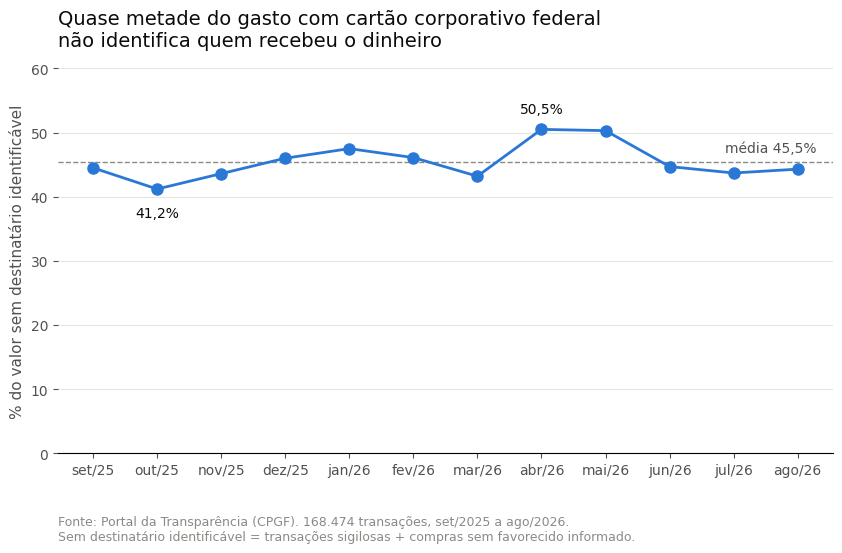

In [18]:
import matplotlib.pyplot as plt

meses_pt = {1: "jan", 2: "fev", 3: "mar", 4: "abr", 5: "mai", 6: "jun",
            7: "jul", 8: "ago", 9: "set", 10: "out", 11: "nov", 12: "dez"}
rotulos = [f"{meses_pt[m]}/{str(a)[2:]}" for a, m in resumo.index]
valores = resumo["% opaco"].values
media = valores.mean()

def virgula(numero):
    return f"{numero:.1f}".replace(".", ",")

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(media, color="#8a8a85", linewidth=1, linestyle="--")
ax.text(11.3, media + 1.5, f"média {virgula(media)}%",
        color="#52514e", fontsize=10, ha="right")

ax.plot(rotulos, valores, color="#2a78d6", linewidth=2, marker="o", markersize=8)

ax.set_ylim(0, 60)
ax.set_ylabel("% do valor sem destinatário identificável", fontsize=11, color="#52514e")
ax.set_title("Quase metade do gasto com cartão corporativo federal\nnão identifica quem recebeu o dinheiro",
             fontsize=14, color="#0b0b0b", loc="left", pad=16)

ax.grid(axis="y", color="#e5e5e2", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(colors="#52514e")

i_min = valores.argmin()
i_max = valores.argmax()
ax.annotate(virgula(valores[i_min]) + "%", (i_min, valores[i_min]),
            textcoords="offset points", xytext=(0, -20), ha="center",
            fontsize=10, color="#0b0b0b")
ax.annotate(virgula(valores[i_max]) + "%", (i_max, valores[i_max]),
            textcoords="offset points", xytext=(0, 12), ha="center",
            fontsize=10, color="#0b0b0b")

ax.text(0, -0.16,
        "Fonte: Portal da Transparência (CPGF). 168.474 transações, set/2025 a ago/2026.\n"
        "Sem destinatário identificável = transações sigilosas + compras sem favorecido informado.",
        transform=ax.transAxes, fontsize=9, color="#8a8a85", va="top")

plt.savefig("grafico1_opacidade_mensal.png", dpi=200, bbox_inches="tight")
plt.show()

### Gráfico 2: do que é feita a opacidade

**O que quero mostrar:** que os R\$ 57,58 milhões sem destinatário identificável têm duas origens distintas, e que uma delas não tem amparo legal declarado.

**Por que uma barra empilhada horizontal:** é um total único (o gasto de 12 meses) dividido em 3 partes. A barra deixa comparar os tamanhos por comprimento, que o olho lê melhor que ângulo, e por isso prefiro ela à pizza. Uso cinza para a parte identificada, que é o "normal", e cores para as duas partes opacas, que são o assunto do gráfico.

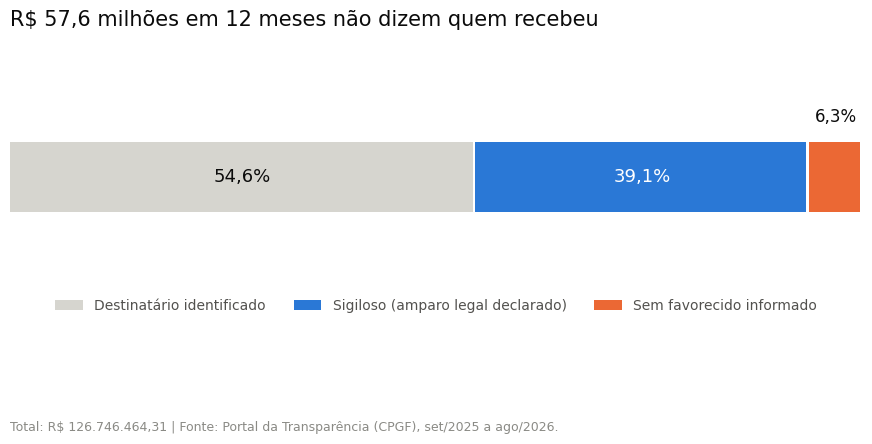

In [19]:
total = todos["VALOR TRANSAÇÃO"].sum()
v_sigiloso = todos.loc[todos["SIGILOSO"], "VALOR TRANSAÇÃO"].sum()
v_sem_fav = todos.loc[todos["SEM FAVORECIDO"], "VALOR TRANSAÇÃO"].sum()
v_identificado = total - v_sigiloso - v_sem_fav

segmentos = [
    ("Destinatário identificado", v_identificado, "#d6d5cf", "#0b0b0b"),
    ("Sigiloso (amparo legal declarado)", v_sigiloso, "#2a78d6", "#ffffff"),
    ("Sem favorecido informado", v_sem_fav, "#eb6834", "#ffffff"),
]

fig, ax = plt.subplots(figsize=(11, 2.8))
folga = total * 0.0025
esquerda = 0

for nome, valor, cor, cor_texto in segmentos:
    ax.barh(0, valor - folga, left=esquerda, height=0.45, color=cor, label=nome)
    pct = valor / total * 100
    if pct >= 10:
        ax.text(esquerda + valor / 2, 0, f"{virgula(pct)}%",
                ha="center", va="center", color=cor_texto, fontsize=13)
    else:
        ax.text(esquerda + valor / 2, 0.33, f"{virgula(pct)}%",
                ha="center", va="bottom", color="#0b0b0b", fontsize=12)
    esquerda += valor

ax.set_xlim(0, total)
ax.set_ylim(-0.6, 0.8)
ax.axis("off")

ax.set_title("R$ 57,6 milhões em 12 meses não dizem quem recebeu",
             fontsize=15, color="#0b0b0b", loc="left", pad=20)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3,
          frameon=False, fontsize=10, labelcolor="#52514e")

ax.text(0, -0.75,
        f"Total: R$ {total:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        + " | Fonte: Portal da Transparência (CPGF), set/2025 a ago/2026.",
        transform=ax.transAxes, fontsize=9, color="#8a8a85")

plt.savefig("grafico2_composicao.png", dpi=200, bbox_inches="tight")
plt.show()

### Gráfico 3: compras sem favorecido, por órgão

**O que quero mostrar:** que existe uma taxa de base comum a quase todo o governo, por volta de 7% das compras, e que a Presidência da República está dez vezes acima dela.

**Por que barras horizontais com uma linha de referência:** a comparação é entre categorias, e barra é a forma mais direta para isso. Na horizontal porque os nomes dos órgãos são longos. A linha vertical marca a taxa geral do governo, e é ela que transforma o gráfico de uma lista em uma comparação: sem a referência, 70,6% é só um número; com ela, fica visível que é um ponto fora da curva. Uso cor diferente apenas na Presidência porque ela é o assunto do gráfico; os demais compartilham a mesma cor porque formam um grupo.

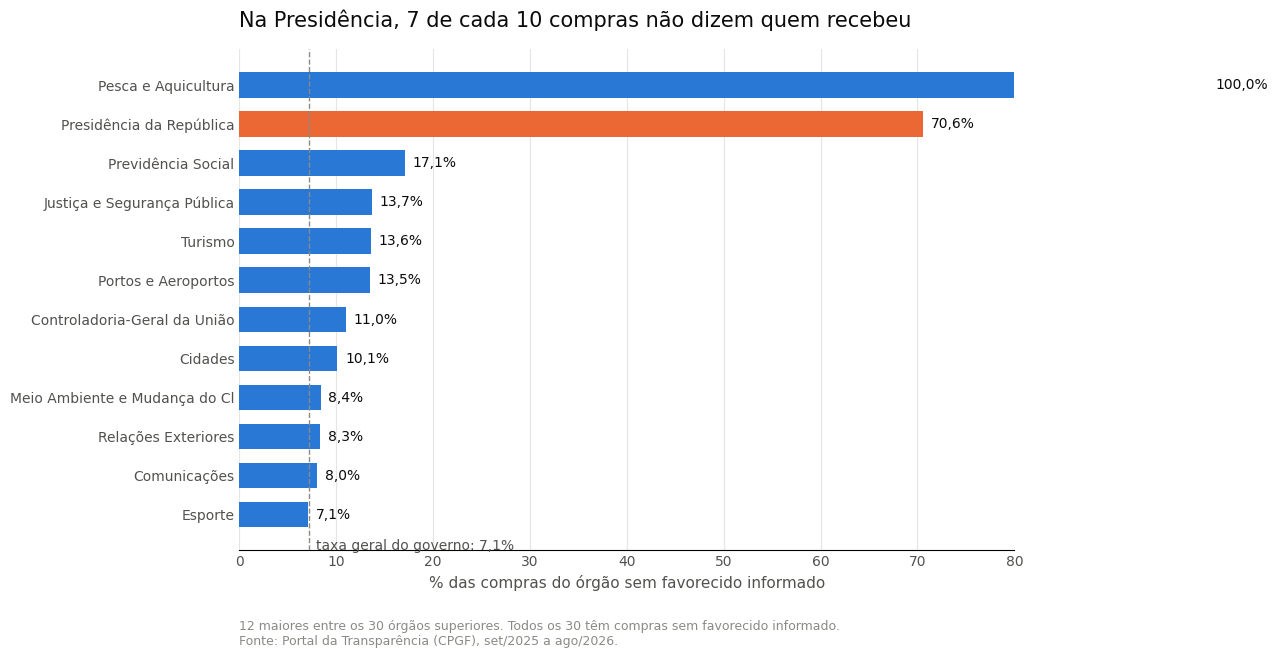

In [20]:
def nome_curto(nome):
    for prefixo in ["Ministério da ", "Ministério do ", "Ministério de ",
                    "Ministério das ", "Ministério dos "]:
        if nome.startswith(prefixo):
            return nome[len(prefixo):]
    return nome

dados = por_orgao_sf.sort_values("% das compras do órgão", ascending=False).head(12)
nomes = [nome_curto(n) for n in dados.index]
percentuais = dados["% das compras do órgão"].values

taxa_geral = len(sem_fav) / len(compras_todas) * 100

fig, ax = plt.subplots(figsize=(10, 6.5))

cores = ["#eb6834" if "Presidência" in n else "#2a78d6" for n in nomes]
posicoes = range(len(nomes))[::-1]

ax.barh(list(posicoes), percentuais, height=0.65, color=cores)

ax.axvline(taxa_geral, color="#8a8a85", linewidth=1, linestyle="--")
ax.text(taxa_geral + 0.8, -0.9, f"taxa geral do governo: {virgula(taxa_geral)}%",
        color="#52514e", fontsize=10)

for y, pct in zip(posicoes, percentuais):
    ax.text(pct + 0.8, y, f"{virgula(pct)}%", va="center", fontsize=10, color="#0b0b0b")

ax.set_yticks(list(posicoes))
ax.set_yticklabels(nomes, fontsize=10, color="#0b0b0b")
ax.set_xlim(0, 80)
ax.set_xlabel("% das compras do órgão sem favorecido informado", fontsize=11, color="#52514e")

ax.set_title("Na Presidência, 7 de cada 10 compras não dizem quem recebeu",
             fontsize=15, color="#0b0b0b", loc="left", pad=16)

ax.grid(axis="x", color="#e5e5e2", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
ax.tick_params(colors="#52514e", length=0)

ax.text(0, -0.14,
        "12 maiores entre os 30 órgãos superiores. Todos os 30 têm compras sem favorecido informado.\n"
        "Fonte: Portal da Transparência (CPGF), set/2025 a ago/2026.",
        transform=ax.transAxes, fontsize=9, color="#8a8a85", va="top")

plt.savefig("grafico3_orgaos.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
checagem = por_orgao_sf.copy()
checagem["compras do órgão"] = total_orgao["count"]
checagem = checagem.rename(columns={"count": "sem favorecido"})

print(checagem.sort_values("% das compras do órgão", ascending=False)
      [["sem favorecido", "compras do órgão", "% das compras do órgão"]].head(12))

                                             sem favorecido  compras do órgão  \
NOME ÓRGÃO SUPERIOR                                                             
Ministério da Pesca e Aquicultura                         1                 1   
Presidência da República                                962              1362   
Ministério da Previdência Social                         24               140   
Ministério da Justiça e Segurança Pública               865              6327   
Ministério do Turismo                                     3                22   
Ministério de Portos e Aeroportos                        13                96   
Controladoria-Geral da União                              8                73   
Ministério das Cidades                                   37               366   
Ministério do Meio Ambiente e Mudança do Cl             260              3078   
Ministério das Relações Exteriores                       33               397   
Ministério das Comunicações 

### Gráfico 3: compras sem favorecido, por órgão

**O que quero mostrar:** que existe uma taxa de base comum a quase todo o governo, por volta de 7% das compras, e que a Presidência da República está muito acima dela.

**Por que barras horizontais com linha de referência:** a comparação é entre categorias, e barra é a forma mais direta. Na horizontal porque os nomes dos órgãos são longos. A linha vertical marca a taxa geral do governo: sem ela, 70,6% é só um número; com ela, fica visível que é um ponto fora da curva.

**Correção aplicada depois de ver a primeira versão:** o gráfico inicial ordenava os órgãos só pela porcentagem, e o Ministério da Pesca e Aquicultura apareceu em primeiro lugar com 100%. Ao conferir o denominador, descobri que esse órgão fez **1 única compra** no ano, e ela ficou sem favorecido. Outros casos parecidos: Esporte (1 de 14) e Turismo (3 de 22). Uma porcentagem calculada sobre poucos casos não é comparável a uma calculada sobre mais de mil, então o gráfico estava sugerindo uma conclusão errada.

**Decisão:** incluir apenas órgãos com pelo menos 100 compras no período, e mostrar a fração (quantas de quantas) ao lado de cada barra, para que o leitor possa julgar o peso de cada percentual. O corte de 100 é arbitrário, por isso está declarado no rodapé do gráfico e aqui.

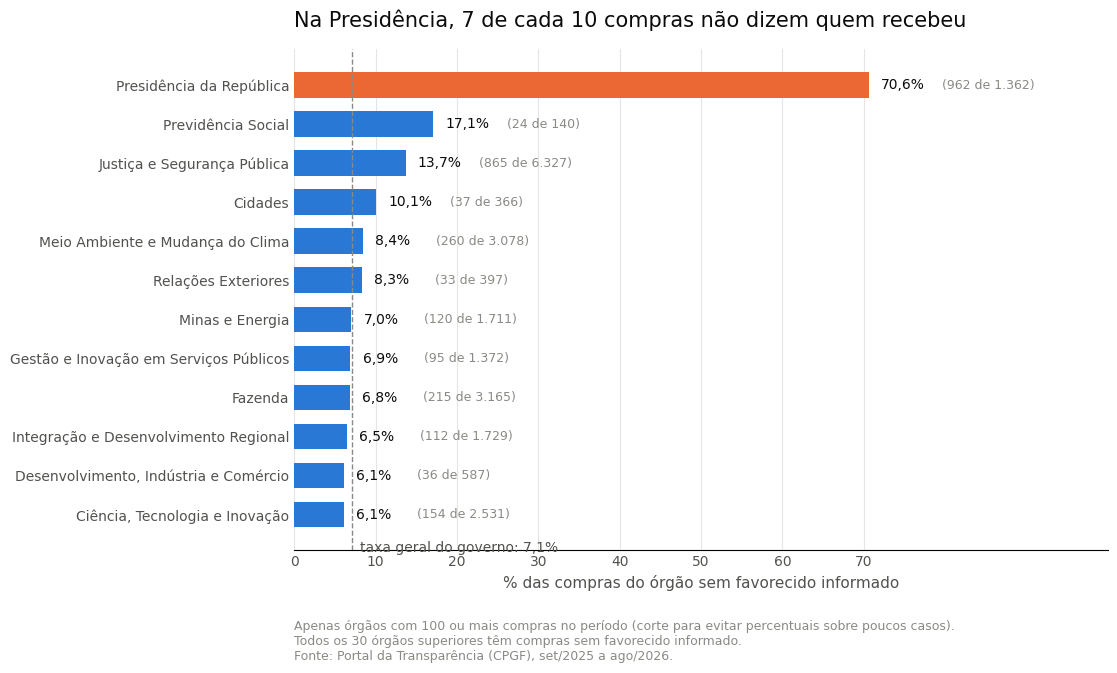

In [23]:
def milhar(n):
    return f"{int(n):,}".replace(",", ".")

base = por_orgao_sf.copy()
base["compras do órgão"] = total_orgao["count"]
base = base[base["compras do órgão"] >= 100]

dados = base.sort_values("% das compras do órgão", ascending=False).head(12)
nomes = [nome_curto(n) for n in dados.index]
nomes_corrigidos = {
    "Meio Ambiente e Mudança do Cl": "Meio Ambiente e Mudança do Clima",
    "Ciência, Tecnologia e Inovaç": "Ciência, Tecnologia e Inovação",
    "Integração e do Desenvolvime": "Integração e Desenvolvimento Regional",
    "Desenvolvimento, Indústria, C": "Desenvolvimento, Indústria e Comércio",
    "Gestão e da Inovação em Ser": "Gestão e Inovação em Serviços Públicos",
    "Desenvolvimento Agrário e Agr": "Desenvolvimento Agrário e Agricultura Familiar",
}

nomes = [nomes_corrigidos.get(nome_curto(n), nome_curto(n)) for n in dados.index]
percentuais = dados["% das compras do órgão"].values
sem_fav_n = dados["count"].values
total_n = dados["compras do órgão"].values

taxa_geral = len(sem_fav) / len(compras_todas) * 100

fig, ax = plt.subplots(figsize=(10.5, 6.5))

cores = ["#eb6834" if "Presidência" in n else "#2a78d6" for n in nomes]
posicoes = list(range(len(nomes))[::-1])

ax.barh(posicoes, percentuais, height=0.65, color=cores)
ax.axvline(taxa_geral, color="#8a8a85", linewidth=1, linestyle="--")
ax.text(taxa_geral + 1, -0.95, f"taxa geral do governo: {virgula(taxa_geral)}%",
        color="#52514e", fontsize=10)

for y, pct, n_sf, n_tot in zip(posicoes, percentuais, sem_fav_n, total_n):
    ax.text(pct + 1.5, y, f"{virgula(pct)}%", va="center", fontsize=10, color="#0b0b0b")
    ax.text(pct + 9, y, f"({milhar(n_sf)} de {milhar(n_tot)})",
            va="center", fontsize=9, color="#8a8a85")

ax.set_yticks(posicoes)
ax.set_yticklabels(nomes, fontsize=10, color="#0b0b0b")
ax.set_xlim(0, 100)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70])
ax.set_xlabel("% das compras do órgão sem favorecido informado", fontsize=11, color="#52514e")

ax.set_title("Na Presidência, 7 de cada 10 compras não dizem quem recebeu",
             fontsize=15, color="#0b0b0b", loc="left", pad=16)

ax.grid(axis="x", color="#e5e5e2", linewidth=0.8)
ax.set_axisbelow(True)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
ax.tick_params(colors="#52514e", length=0)

ax.text(0, -0.14,
        "Apenas órgãos com 100 ou mais compras no período (corte para evitar percentuais sobre poucos casos).\n"
        "Todos os 30 órgãos superiores têm compras sem favorecido informado.\n"
        "Fonte: Portal da Transparência (CPGF), set/2025 a ago/2026.",
        transform=ax.transAxes, fontsize=9, color="#8a8a85", va="top")

plt.savefig("grafico3_orgaos.png", dpi=200, bbox_inches="tight")
plt.show()

### Pergunta: o valor por transação é diferente entre os grupos?

**Por que isso importa:** até agora comparei os grupos pelo total gasto. Mas total alto pode vir de muitas transações pequenas ou de poucas transações grandes, e isso muda a leitura. Se uma transação sigilosa for, em média, muito maior que uma compra comum, isso é uma informação nova: significa que o sigilo não cobre o gasto miúdo do dia a dia, e sim as operações de maior valor. Preciso medir antes de afirmar, porque no total do ano o gasto sigiloso (R\$ 49,57 milhões) é menor que o identificado (R\$ 69,17 milhões), e seria fácil confundir as duas coisas.

**Como vou responder:** separar as transações em quatro grupos que não se misturam e comparar, em cada um, a quantidade, o total, a média, a mediana e o maior valor. Os quatro grupos são: sigilosas, saques, compras sem favorecido e compras identificadas. Os saques ficam à parte porque não têm estabelecimento recebedor, e misturá-los com as compras distorceria a comparação. Vou conferir no final se a soma dos quatro grupos bate com o total de transações, para garantir que nenhuma ficou de fora nem foi contada duas vezes.

**O que o resultado mostrou:**

| Grupo | Transações | Valor total | Média | Mediana | Maior |
|---|---|---|---|---|---|
| Sigiloso | 43.030 | R\$ 49.565.348,32 | R\$ 1.151,88 | R\$ 1.000,00 | R\$ 185.023,51 |
| Saque | 14.051 | R\$ 9.402.338,45 | R\$ 669,16 | R\$ 700,00 | R\$ 20.000,00 |
| Compra sem favorecido | 7.954 | R\$ 8.012.311,69 | R\$ 1.007,33 | R\$ 368,00 | R\$ 80.766,40 |
| Compra identificada | 103.439 | R\$ 59.766.465,85 | R\$ 577,79 | R\$ 266,47 | R\$ 52.343,80 |

**Por transação, a diferença é grande.** A mediana de uma transação sigilosa é R\$ 1.000,00, quase quatro vezes a de uma compra identificada (R\$ 266,47). A maior transação de todo o período também é sigilosa: R\$ 185.023,51. Ou seja, embora o gasto sigiloso seja menor que o identificado no total do ano, ele é composto de transações individualmente muito maiores.

**Os valores sigilosos são anormalmente redondos:**

- **80,1%** das transações sigilosas são múltiplas de 50, contra **14,0%** das compras identificadas.
- O valor **R\$ 1.000,00 aparece 32.502 vezes**, ou seja, em **75,5% de todas as transações sigilosas**. Isso soma R\$ 32,5 milhões, 65,6% de todo o valor sigiloso do período.
- Os demais valores frequentes também são redondos: R\$ 500,00 (373 vezes), R\$ 600,00 (210), R\$ 900,00 (125).

**O que isso sugere:** compras em estabelecimentos comerciais não produzem essa distribuição. Preços reais raramente caem em valores redondos, e é por isso que as compras identificadas só têm 14% de múltiplos de 50. Uma concentração de três quartos das transações num único valor exato indica que esses registros não são preços de compras, e sim valores padronizados.

**Duas hipóteses, que os dados não decidem:**
1. O valor publicado para transações sigilosas pode ser substituído por um valor padrão, e não ser o valor real da transação.
2. Podem ser repasses ou adiantamentos de valor fixo, e não compras em estabelecimentos.

**Consequência para esta análise:** se a hipótese 1 estiver correta, o total de R\$ 49,57 milhões em transações sigilosas não corresponde ao valor efetivamente gasto, e não há como saber, a partir dos dados públicos, se o valor real é maior ou menor. Essa incerteza afeta o número de 45,4% apresentado como resultado principal, que passa a ser uma medida de **quantas transações não são rastreáveis**, e não uma medida exata de quanto dinheiro elas movimentaram.

In [24]:
e_saque = todos["TRANSAÇÃO"].str.startswith("SAQUE")

grupos = {
    "Sigiloso": todos[todos["SIGILOSO"]],
    "Saque": todos[e_saque],
    "Compra sem favorecido": todos[todos["SEM FAVORECIDO"]],
    "Compra identificada": todos[todos["TRANSAÇÃO"].str.startswith("COMP") & ~todos["SEM FAVORECIDO"]],
}

linhas = []
for nome, g in grupos.items():
    linhas.append({
        "Grupo": nome,
        "Transações": len(g),
        "Valor total": g["VALOR TRANSAÇÃO"].sum(),
        "Média": g["VALOR TRANSAÇÃO"].mean(),
        "Mediana": g["VALOR TRANSAÇÃO"].median(),
        "Maior": g["VALOR TRANSAÇÃO"].max(),
    })

perfil = pd.DataFrame(linhas).set_index("Grupo").round(2)
print(perfil)
print()
print("Soma das transações dos 4 grupos:", perfil["Transações"].sum(), "de", len(todos))

                       Transações  Valor total    Média  Mediana      Maior
Grupo                                                                      
Sigiloso                    43030  49565348.32  1151.88  1000.00  185023.51
Saque                       14051   9402338.45   669.16   700.00   20000.00
Compra sem favorecido        7954   8012311.69  1007.33   368.00   80766.40
Compra identificada        103439  59766465.85   577.79   266.47   52343.80

Soma das transações dos 4 grupos: 168474 de 168474


In [25]:
sigilosas = todos[todos["SIGILOSO"]]
compras_id = todos[todos["TRANSAÇÃO"].str.startswith("COMP") & ~todos["SEM FAVORECIDO"]]

def pct_redondos(serie):
    return round((serie % 50 == 0).mean() * 100, 1)

print("Sigilosas múltiplas de 50:", pct_redondos(sigilosas["VALOR TRANSAÇÃO"]), "%")
print("Compras identificadas múltiplas de 50:", pct_redondos(compras_id["VALOR TRANSAÇÃO"]), "%")
print()
print("Valores sigilosos mais frequentes:")
print(sigilosas["VALOR TRANSAÇÃO"].value_counts().head(10))

Sigilosas múltiplas de 50: 80.1 %
Compras identificadas múltiplas de 50: 14.0 %

Valores sigilosos mais frequentes:
VALOR TRANSAÇÃO
1000.0    32502
500.0       373
600.0       210
900.0       125
200.0       105
400.0        99
800.0        93
700.0        89
150.0        87
300.0        80
Name: count, dtype: int64
